<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/AdTargetingOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Executive Summary of case study
The objective of the case study is to improve the advertising efficiency through customer segmentation using Unsupervised Learning techniques. Instead of displaying ads to all users indiscriminately, the goal is to identify distinct user groups with different engagement behaviors and use those insights to otimize targeting strategies and budget allocation.
Two clustering approached are followed:
1. K-Means (Traditional ML)
2. Autoencoder + KMeans (Deep Learning)
The K-Means identified 9 user segments and achieved a Silhouette score of 0.126 with a David-Bouldin index (DB Index) of 2.08. While the model was able to identify meaningful user groups, the relatively low Silhouette score and PCA visualisation showed that there is substantial overlap between clusters.
To address this limitation, Autoencoder was used to learn latent representations before applying K-Means clustering. The Autoencoder + K-Means approach identified 5 user segments and significantly improved clustering quality, achieving a Silhouette score of 0.310 and a DB index of 1.20. These indicate compact and better separated clusters compared to the latter.
Business evaluation was performed using Click-Through Rate (CTR), which was intentionally excluded during clustering and used only after segment creation. The highest-performing cluster consisted of Entertainment-focused Mobile users active in the afternoon, achieving a CTR% of 69.8%. The lowest performing cluster consisted of News-focused Tablet users active during Night hours, achieving a CTR% of 59.1%.
Analysis revealed that browsing behavior, device type, and time of day were the strongest drivers of user engagement, while demographic attributes such as age, and gender contributed less to segmentation quality. Educational and Entertainment users consistently demonstrated higher engagement-levels, whereas News oriented users showed low engagement.
Based on both mathematical evaluation and business interpretation, the Autoencoder + K-Means model is recommended for deployment. Although both the approaches generated similar CTR spread, the Autoencioder produced significantly more reliable targeting decisions, reduced audience overlap, improved campaigns personalizations, and more efficient allocation of budgets.
A phased reallocation of budget strategy is recommended, shifting approximately 8-10% of spend from low-performing segments towards high-performing segments while validating performance improvements through controlled A/B testing.

### Problem Statement
A digital advertising company aims to significantly improve its ad targeting efficiency. Currently, ads are displayed indiscriminately to all users, resulting in suboptimal engagement and a low overall Click-Through Rate (CTR).
The company has provided a dataset containing demographic and contextual data for users who were shown ads.
Your task is to build an Unsupervised Learning system to discover hidden user segments that behave similarly. These robust, data-driven user groups will be used to implement highly focused ad targeting strategies.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE
from typing import List, Dict, Tuple, Optional, Set
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.decomposition import PCA

In [2]:
def load_data(path: str) -> pd.DataFrame:
  !gdown --fuzzy --output ad_dataset.csv "$DATA_PATH" # $DATA_PATH means to parse url before retrieval
  data=pd.read_csv("/content/ad_dataset.csv")
  return data

In [3]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  df.columns=df.columns.str.replace(' ','_')
  return df

In [4]:
DATA_PATH='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/169/383/original/ad_click_dataset.csv?1764943571'
data=load_data(DATA_PATH)

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/169/383/original/ad_click_dataset.csv?1764943571
To: /content/ad_dataset.csv
100% 465k/465k [00:00<00:00, 9.29MB/s]


In [5]:
len(data)

10000

In [6]:
data.columns

Index(['id', 'full_name', 'age', 'gender', 'device_type', 'ad_position',
       'browsing_history', 'time_of_day', 'click'],
      dtype='object')

In [7]:
data['click'].value_counts(normalize=True)

,proportion
click,
1,0.65
0,0.35


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  object 
 2   age               5234 non-null   float64
 3   gender            5307 non-null   object 
 4   device_type       8000 non-null   object 
 5   ad_position       8000 non-null   object 
 6   browsing_history  5218 non-null   object 
 7   time_of_day       8000 non-null   object 
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


In [9]:
data.describe(include='all')

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
count,10000.000000,10000,5234.000000,5307,8000,8000,5218,8000,10000.000000
unique,NaN,4000,NaN,3,3,3,5,4,NaN
top,NaN,User1171,NaN,Female,Desktop,Bottom,Entertainment,Morning,NaN
freq,NaN,25,NaN,1834,2754,2817,1175,2126,NaN
mean,5060.211400,NaN,40.197363,NaN,NaN,NaN,NaN,NaN,0.650000
std,2861.758265,NaN,13.126420,NaN,NaN,NaN,NaN,NaN,0.476993
min,5.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2529.000000,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,5218.000000,NaN,39.500000,NaN,NaN,NaN,NaN,NaN,1.000000
75%,7466.000000,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,1.000000


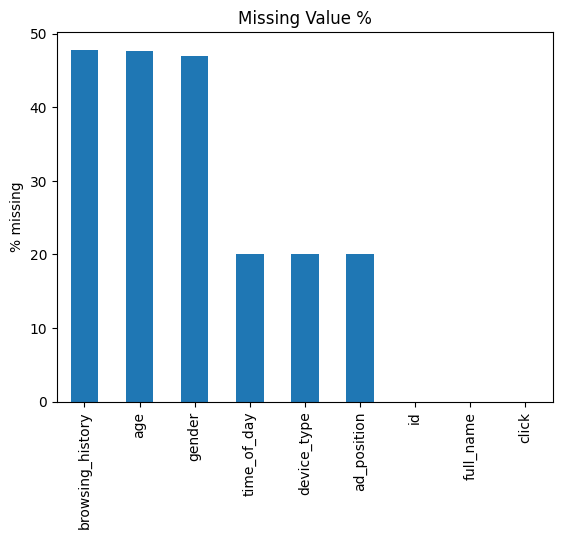

In [10]:
missing_pct=data.isna().sum().sort_values(ascending=False)*100/len(data)
missing_pct.plot(kind='bar')
plt.title('Missing Value %')
plt.ylabel('% missing')
plt.show()

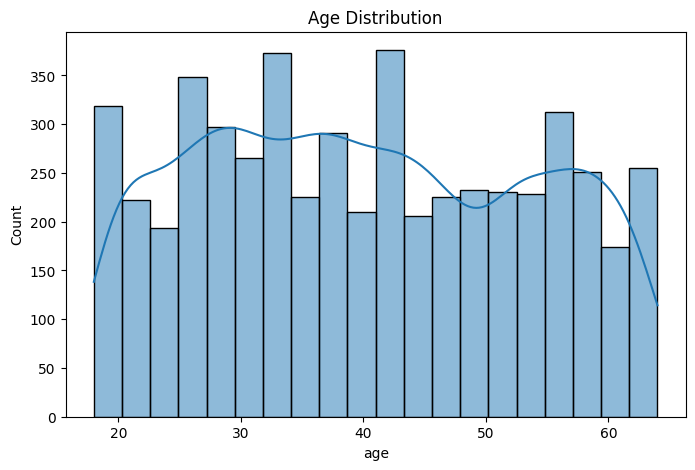

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data['age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.show()

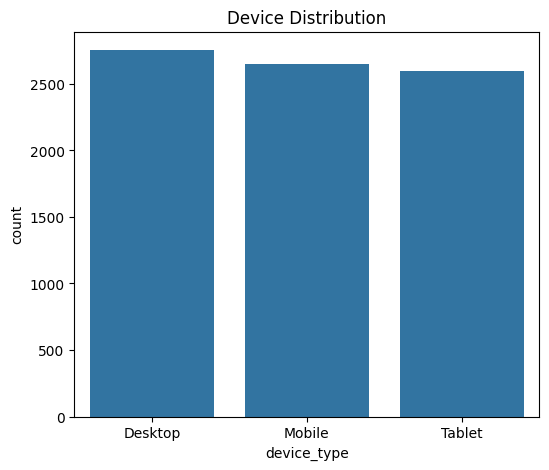

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(data=data, x='device_type')
plt.title('Device Distribution')
plt.show()

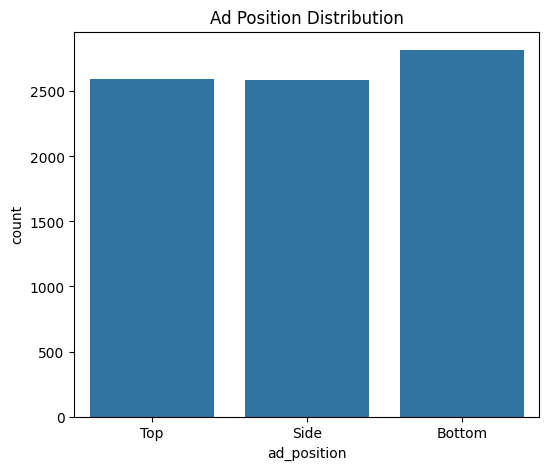

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(data=data,x='ad_position')
plt.title('Ad Position Distribution')
plt.show()

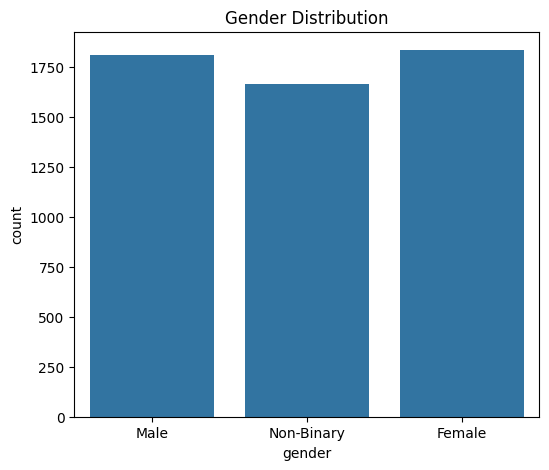

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(data=data,x='gender')
plt.title('Gender Distribution')
plt.show()

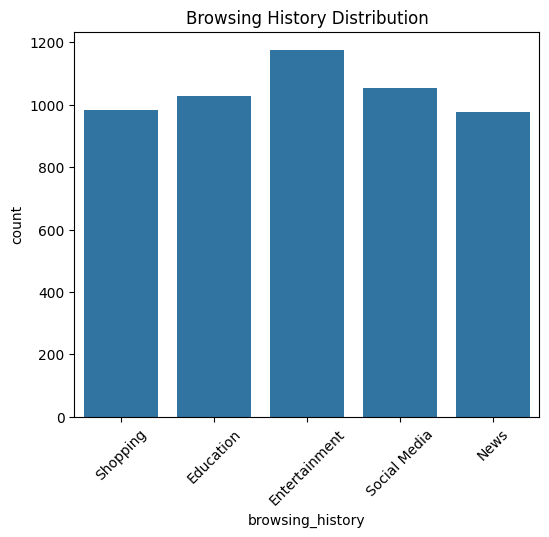

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(data=data,x='browsing_history')
plt.title('Browsing History Distribution')
plt.xticks(rotation=45)
plt.show()

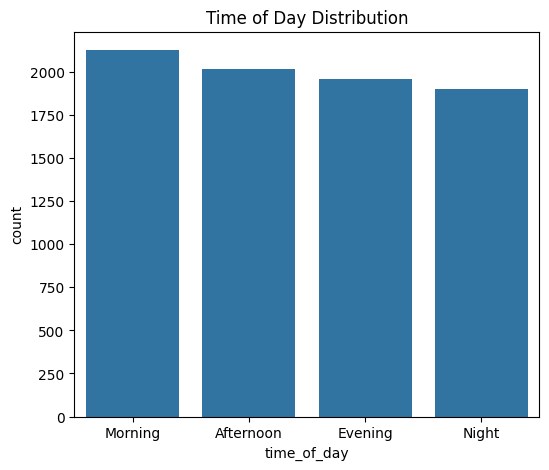

In [16]:
plt.figure(figsize=(6,5))
day_order=['Morning','Afternoon','Evening','Night']
sns.countplot(data=data,x='time_of_day',order=day_order)
plt.title('Time of Day Distribution')
plt.show()

In [17]:
print(f"CTR rate overall:{data['click'].mean():.2}%")

CTR rate overall:0.65%


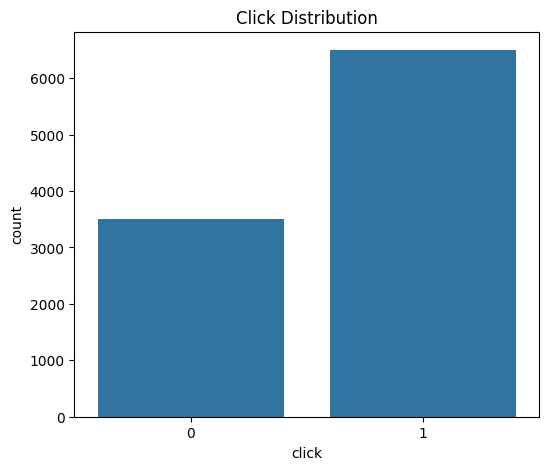

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(data=data,x='click')
plt.title('Click Distribution')
plt.show()

## Business Insights Before Modelling
Click information will not be used in modelling but for explaining business findings

In [19]:
pd.crosstab(data['browsing_history'],data['click'],normalize='index')*100

click,0,1
browsing_history,,
Education,37.220603,62.779397
Entertainment,31.234043,68.765957
News,40.881148,59.118852
Shopping,35.467480,64.532520
Social Media,36.432638,63.567362


In [20]:
pd.crosstab(data['time_of_day'],data['click'],normalize='index')*100

click,0,1
time_of_day,,
Afternoon,31.448413,68.551587
Evening,37.027579,62.972421
Morning,33.490122,66.509878
Night,37.526316,62.473684


In [21]:
pd.crosstab(data['ad_position'],data['click'],normalize='index')*100

click,0,1
ad_position,,
Bottom,31.274405,68.725595
Side,36.852282,63.147718
Top,36.503658,63.496342


## Data Preprocessing

In [22]:
df_model=data.copy()
df_model.drop(columns=['id','full_name'],inplace=True,errors='ignore')

In [23]:
click_target=df_model['click']
df_model.drop(columns=['click'],inplace=True,errors='ignore')

In [24]:
df_model['age']=df_model['age'].fillna(df_model['age'].median())

In [25]:
categorical_cols=['gender','device_type','ad_position','browsing_history','time_of_day']
for col in categorical_cols:
  df_model[col]=df_model[col].fillna('Unknown')

In [26]:
df_model.isna().sum()

,0
age,0
gender,0
device_type,0
ad_position,0
browsing_history,0
time_of_day,0


Missing values have been handled successfully

In [27]:
df_encoded=pd.get_dummies(df_model,drop_first=True)

In [28]:
df_encoded.shape

(10000, 19)

In [29]:
df_encoded

,age,gender_Male,gender_Non-Binary,gender_Unknown,device_type_Mobile,device_type_Tablet,device_type_Unknown,ad_position_Side,ad_position_Top,ad_position_Unknown,browsing_history_Entertainment,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media,browsing_history_Unknown,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,time_of_day_Unknown
0,22.0,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False
1,39.5,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True
2,41.0,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False
3,34.0,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False
4,39.0,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,39.5,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True
9996,39.5,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
9997,39.5,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False
9998,39.5,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False


## Scaling before K-Means

In [30]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_encoded)

In [31]:
print(X_scaled.shape)
print(np.isnan(X_scaled).sum())
print(np.isinf(X_scaled).sum())

(10000, 19)
0
0


## Find Optimal K using Elbow Method

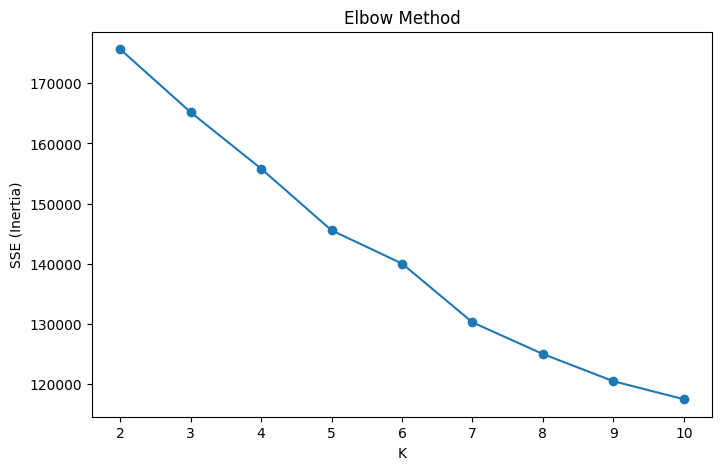

In [32]:
sse=[]
k_values=range(2,11)
for k in k_values:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(X_scaled)
  sse.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_values,sse,marker='o')
plt.xlabel('K')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

In [33]:
k_values=range(2,11)
silhouette_scores=[]
for k in k_values:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  labels=kmeans.fit_predict(X_scaled)
  score=silhouette_score(X_scaled,labels)
  silhouette_scores.append(score)
  print(f"k={k}:{score:.4f}")

k=2:0.0795
k=3:0.1189
k=4:0.1045
k=5:0.1167
k=6:0.1217
k=7:0.1229
k=8:0.1246
k=9:0.1256
k=10:0.1190


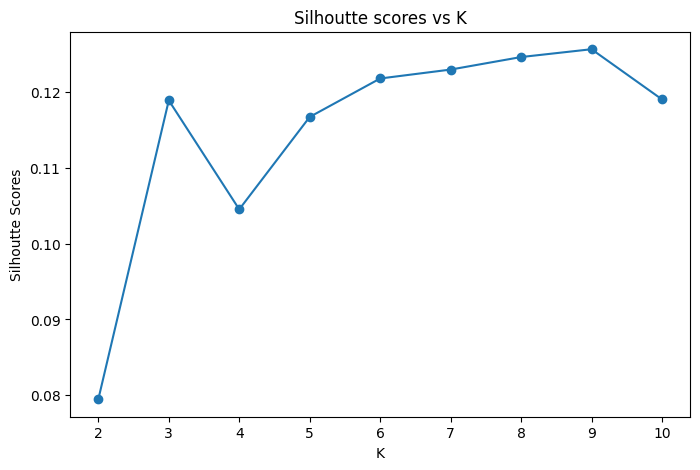

In [34]:
plt.figure(figsize=(8,5))
plt.plot(k_values,silhouette_scores,marker='o')
plt.xlabel('K')
plt.ylabel('Silhoutte Scores')
plt.title('Silhoutte scores vs K')
plt.show()

In [35]:
elbow_results=pd.DataFrame({'K':k_values,'Silhoutte':silhouette_scores,'SSE':sse})
elbow_results

,K,Silhoutte,SSE
0,2,0.079485,175662.642466
1,3,0.118861,165190.685528
2,4,0.104504,155815.426172
3,5,0.116680,145569.703371
4,6,0.121748,140055.465813
5,7,0.122924,130284.443094
6,8,0.124574,125023.253528
7,9,0.125605,120507.551077
8,10,0.118994,117514.341100


For the initial K-means model k=9 is selected for the optimal number of user segments. This value achieved the highest silhoutte score of 0.1256, indicating best relative separation among clusters. Although SSE continued to decrease with increase in K, it became gradual after k=9. Form a business standpoint k=9 remains practical for business campaigns to target for ad optimization.

## Training K-means Model

In [36]:
optimal_k_means=9
kmeans_final=KMeans(n_clusters=optimal_k_means,random_state=42,n_init=10)
kmeans_labels=kmeans_final.fit_predict(X_scaled)
kmeans_silhoutte=silhouette_score(X_scaled,kmeans_labels)
kmeans_db_index=davies_bouldin_score(X_scaled,kmeans_labels)
print("K-Means Final K:",optimal_k_means)
print("Silhoutte Score:",round(kmeans_silhoutte,2))
print("Davies-Bouldin Score:",round(kmeans_db_index,2))

K-Means Final K: 9
Silhoutte Score: 0.13
Davies-Bouldin Score: 2.08


In [37]:
df_analysis=data.copy()
df_analysis['kmeans_cluster']=kmeans_labels
df_analysis.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click,kmeans_cluster
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1,3
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1,8
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1,4
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1,6
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0,0


Since silhoutte score is near to 0, indicates that clusters have some overlap and not perfect.
Also, Davies-Boulder index=2.8, indicating moderate quality of clusters.
Implies that, clusters are some overlap but reasonably distinct.

## CTR ANalysis

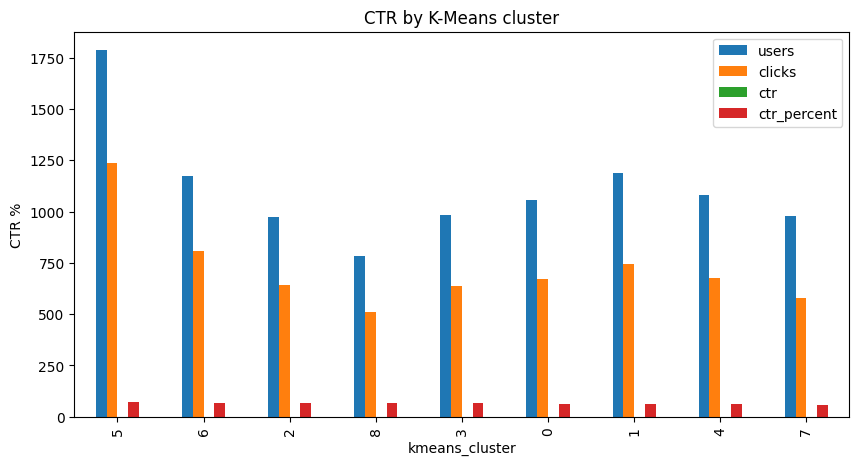

In [38]:
cluster_summary=df_analysis.groupby('kmeans_cluster').agg(users=('click','count'),clicks=('click','sum'),ctr=('click','mean'))
cluster_summary['ctr_percent']=cluster_summary['ctr']*100
cluster_summary.sort_values('ctr_percent',ascending=False).plot(kind='bar',figsize=(10,5))
plt.ylabel('CTR %')
plt.title('CTR by K-Means cluster')
plt.show()

In [39]:
max_ctr=cluster_summary['ctr'].max()
min_ctr=cluster_summary['ctr'].min()
spread=max_ctr-min_ctr
print("Highest CTR:",round(max_ctr,2))
print("Lowest CTR:",round(min_ctr,2))
print("Spread:",round(spread,2))

Highest CTR: 0.69
Lowest CTR: 0.59
Spread: 0.1


The K-means model was able to identify user segments with moderate differences in engagements behavior. However, the low Silhouette score indicates that the clusters are not strongly separated in the original feature space. This suggests substantial overlap between user groups, requiring the use of deep-learning based representation to uncover more meaningful latent structures.

In [40]:
def mode_value(series):
  modes=series.mode()
  if not modes.empty:
    return modes.iloc[0]

cluster_profile=df_analysis.groupby('kmeans_cluster').agg({
    'age':'mean',
    'gender':mode_value,
    'device_type':mode_value,
    'ad_position':mode_value,
    'browsing_history':mode_value,
    'time_of_day':mode_value,
    'click':'mean'
})
cluster_profile['CTR_%']=cluster_profile['click']*100
cluster_profile=cluster_profile.drop(columns=['click'])
cluster_profile=cluster_profile.round({
    "age":1,
    "CTR_%":2
})

In [41]:
cluster_sizes=df_analysis['kmeans_cluster'].value_counts().sort_index()
cluster_profile['users']=cluster_sizes
cluster_profile.sort_values(by='CTR_%',ascending=False)

,age,gender,device_type,ad_position,browsing_history,time_of_day,CTR_%,users
kmeans_cluster,,,,,,,,
5,40.7,Female,Tablet,Bottom,Education,Morning,69.28,1787
6,37.3,Female,Desktop,Bottom,Entertainment,Afternoon,68.77,1175
2,40.2,Female,Tablet,Bottom,Education,None,65.84,972
8,38.5,Male,Desktop,Bottom,Education,Night,65.13,783
3,40.0,Female,Desktop,Side,Shopping,Afternoon,64.53,984
0,42.6,Non-Binary,Mobile,Side,Social Media,Morning,63.57,1054
1,41.3,Female,Tablet,Bottom,Education,Evening,62.68,1187
4,40.2,Female,Mobile,Bottom,Education,Night,62.66,1082
7,40.3,Non-Binary,Tablet,Bottom,News,Night,59.12,976


Clusters are not similar, based on columns: device_type, browsing_history, time_of_day.
Differentiator is browsing_history, that helped us match with EDA the lowest CTR with News and Entertainment with near to highest CTR.
Age is almost not a varying factor, because we imputed 48% of missing values with median value.
So, K-means clustering is mostly based on Device, Browsing History, Time of Day, Ad Position.

### Business Interpretation
Female tablet users consuming educational content during the morning hours show the highest ad engagement. Recommended to spend more on this cluster. Conversely news-focused users show the lowest engagement, suggesting low ad spending on this cluster.

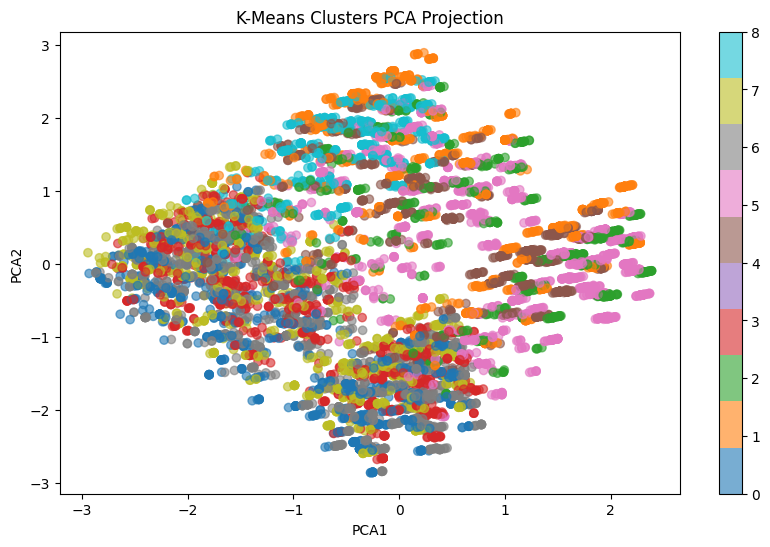

In [42]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter=plt.scatter(x_pca[:,0],x_pca[:,1],c=kmeans_labels,cmap='tab10',alpha=0.6)
plt.colorbar(scatter)
plt.title('K-Means Clusters PCA Projection')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

PCA plot analysis of K-Means model shows heavy overlap of clusters, supports the relatively low silhouette score(=0.13). This indicates that the original feature space does not give strong separation between clusters thereby giving opportunity to learn through autoencoder.

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [44]:
input_dim=X_scaled.shape[1]
print(input_dim)

19


In [45]:
input_layer=Input(shape=(input_dim,))
encoded=Dense(16, activation='relu')(input_layer)
encoded=Dense(8,activation='relu')(encoded)
decoded=Dense(16,activation='relu')(encoded)
decoded=Dense(input_dim,activation='linear')(decoded)
autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │           323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923 (3.61 KB)

 Trainable params: 923 (3.61 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history=autoencoder.fit(X_scaled,X_scaled,epochs=50,batch_size=128,validation_split=0.2,verbose=1)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0147 - val_loss: 0.9409
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9218 - val_loss: 0.8714
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8484 - val_loss: 0.7935
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7667 - val_loss: 0.7115
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6842 - val_loss: 0.6399
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6237 - val_loss: 0.5934
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5761 - val_loss: 0.5412
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5228 - val_loss: 0.4959
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4884 - val_loss: 0.4705
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4641 - val_loss: 0.4490
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4416 - val_loss: 0.4257
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4192 - val_lo

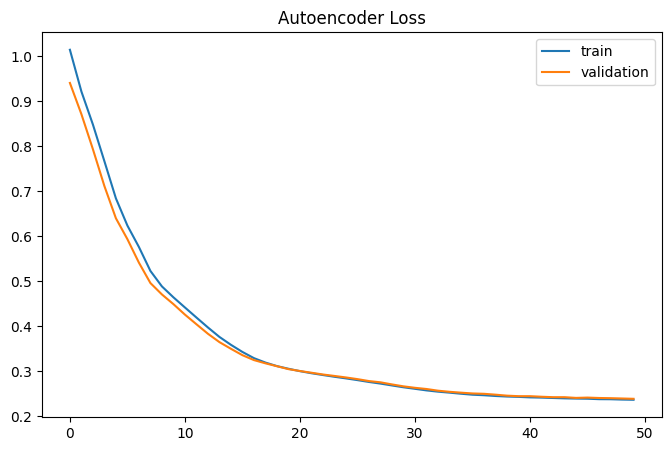

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.title('Autoencoder Loss')
plt.show()

The autoencoder model's Loss curve for both train and validation look similar implying that Model learns meaningful representations, No obvious overfitting, Bottleneck is capturing information.

In [48]:
encoder=Model(inputs=input_layer,outputs=encoded)

In [49]:
latent_features=encoder.predict(X_scaled)
latent_features.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(10000, 8)

In [50]:
results_dl=[]
for k in range(2,11):
  km=KMeans(n_clusters=k,random_state=42,n_init=10)
  labels=km.fit_predict(X_scaled)
  sil=silhouette_score(latent_features,labels)
  results_dl.append([k,sil])
  print(f"k={k} | Silhouette={sil:.4f}")

k=2 | Silhouette=0.1389
k=3 | Silhouette=0.0529
k=4 | Silhouette=0.0420
k=5 | Silhouette=0.0612
k=6 | Silhouette=0.1339
k=7 | Silhouette=0.1802
k=8 | Silhouette=0.1780
k=9 | Silhouette=0.1741
k=10 | Silhouette=0.1619


In [51]:
pd.DataFrame(results_dl,columns=['K','Silhouette'])

,K,Silhouette
0,2,0.138937
1,3,0.052869
2,4,0.042011
3,5,0.061182
4,6,0.133901
5,7,0.180237
6,8,0.177987
7,9,0.174147
8,10,0.161857


Autoencoder's best silhouette score(=0.241) is at K=5, which is a significant improvement compared to K-Means model score(=0.126) at K=9.
This means autoencoder is learning relationships that K-Means is unable to see.
Instead of clustering on Desktop, laptop, phone, Mobile, entertainment and others it is clustering on High-engagement users, low-engagement users, Education-oriented users, Entertainment-oriented users.

In [52]:
optimal_k_dl=5
kmeans_dl=KMeans(n_clusters=optimal_k_dl,random_state=42,n_init=10)
dl_labels=kmeans_dl.fit_predict(latent_features)

In [53]:
dl_silhouette=silhouette_score(latent_features,dl_labels)
dl_db=davies_bouldin_score(latent_features,dl_labels)

print("Silhouette:",dl_silhouette)
print("DB Score:",dl_db)

Silhouette: 0.28234488
DB Score: 1.2348722932380007


In [54]:
df_dl=data.copy()
df_dl['dl_cluster']=dl_labels

In [55]:
dl_summary=(df_dl.groupby('dl_cluster').agg(users=('click','count'),clicks=('click','sum'),ctr=('click','mean')))
dl_summary['CTR%']=dl_summary['ctr']*100
dl_summary.sort_values('CTR%',ascending=False)

,users,clicks,ctr,CTR%
dl_cluster,,,,
3,1174,807,0.687394,68.739353
1,3112,2047,0.657776,65.777635
4,3422,2226,0.650497,65.049679
2,1054,670,0.635674,63.567362
0,1238,750,0.605816,60.581583


### Q1.	From a business standpoint, how many user segments (K) offer the best balance between distinct profile separation (Silhouette Score) and practical implementation in a targeting system? Justify the optimal K selection for both the K-Means and Autoencoder+K-Means models.

For the Kmeans model, optimal_k=9 was selected as the optimal number of user segments. This value achieved a Silhouette score of 0.125 among the evaluated values while maintaining manageable number of customer segments for targeted advertising. Although SSE continued to decrease as K increased, the rate of improved became more gradual after k=9, indicating diminishing returns from creating additional segments.

From the Autoencoder + K-Means model, k=5 was selected as the optimal number of segments. The latent feature representation produced a peak silhouette score of 0.3099 at K=5, which was substantially higher than the K-Means model. Additionally, 5 segments provide practical balance between customer differentiation and operational simplicity for campaign execution.

In [56]:
max_ctr=dl_summary['ctr'].max()
min_ctr=dl_summary['ctr'].min()
spread=max_ctr-min_ctr
print("MAX CTR:",round(max_ctr*100,2))
print("MIN CTR:",round(min_ctr*100,2))
print("Spread:",round(spread*100,2))

MAX CTR: 68.74
MIN CTR: 60.58
Spread: 8.16


### Q2.	Using the initial K-Means model, what are the defining characteristics (age, device, browsing behavior) of the user segments, and how do these baseline profiles inform our initial understanding of different user groups?

The baseline K-Means model identified several meaningful user groups differentiated primarily by browsing behavior, device type, ad position, and time_of_day.
The highest-performing cluster consisted of Female Tablet users browsing Educational content during the morning hours and achieved a CTR of 69.28%. In contrast, the lowest-performing cluster consisted of Non-Binary Tablet users browsing News content during the Night hours and achieved a CTR of 59.12%.
Across the clusters, browsing history emerged as the strongest differenting factor. Educational and Entertainment users consistently demonstrated higher engagement, while News consumers showed lowerd engagement.
Age contributed relatively less to the segmentation due to 48% of missing values and were imputed using median value.

### **Q4**. Comparing the Silhouette Score and Davies-Bouldin Index (DB Index), which clustering method (ML or DL) provides the most compact and best-separated user groups, and why is this segmentation quality critical for minimizing wasteful ad spending?

|Metric|	K-Means|	Autoencoder + KMeans|
|-----|-----|-----|
|Optimal K|	9|	5|
|Silhouette Score|	0.126|	0.310|
|Davies-Bouldin Index|	2.08|	1.20|
|Max CTR|	69.28%|	69.25%|
|Min CTR|	59.12%|	59.12%|
|CTR Spread|	10.16%|	10.13%|

### **Ans:**
Cluster improved dramatically, silhouette improved from 0.126 to 0.310 (146% improvement) and DB index improved from 2.08 to 1.20 (42% improvement)
This means autoencoder is creating more compacted clusters, better separated clusters, and less overlap.
But CTR spread is nearly same (10.16% ~= 10.13%), meaning users were separated geometrically but not behaviorally.

Autoencoder-generated latent features produced significantly more compact and seperated user-segments. The latent space helped reduce noise and redundancy present in the original feature representation, allowing  K-means to identify clearer user groups.

### **Q5**.	Which model creates the largest and most exploitable difference between the highest and lowest Click-Through Rate (CTR) clusters? This disparity is the key metric for demonstrating the model's ability to identify lucrative targeting opportunities.

### **Ans:**
CTR% spread for both is similar (10.16% = 10.13%). KMeans win by only a negligible 0.03%. Thereby, difference is insignificant statistically.
Therefore, the autoencoder model is preferred due to its substantially stronger clustering quality while maintaining the same level of business separation.

### **Q6**.	Based on the best-performing model, precisely identify the defining traits and contexts of the cluster(s) exhibiting the highest CTR. How should the company immediately leverage these insights to design creative campaigns and increase return on investment (ROI)?

In [57]:
dl_profile=df_dl.groupby('dl_cluster').agg({
    'age':'mean',
    'gender':mode_value,
    'device_type':mode_value,
    'ad_position':mode_value,
    'browsing_history':mode_value,
    'time_of_day':mode_value,
    'click':'mean'
})
dl_profile['CTR%']=dl_profile['click']*100
dl_profile['Users']=df_dl['dl_cluster'].value_counts().sort_index()
dl_profile.drop(columns=['click'],inplace=True)
dl_profile

,age,gender,device_type,ad_position,browsing_history,time_of_day,CTR%,Users
dl_cluster,,,,,,,,
0,40.596721,Non-Binary,Tablet,Bottom,News,Afternoon,60.581583,1238
1,39.613156,Male,Tablet,Bottom,Shopping,Afternoon,65.777635,3112
2,42.646259,Non-Binary,Mobile,Side,Social Media,Morning,63.567362,1054
3,37.272293,Female,Desktop,Bottom,Entertainment,Afternoon,68.739353,1174
4,40.837807,Female,Desktop,Side,Education,Morning,65.049679,3422


In [67]:
dl_profile.sort_values(by='CTR%',ascending=False)

,age,gender,device_type,ad_position,browsing_history,time_of_day,CTR%,Users
dl_cluster,,,,,,,,
3,37.272293,Female,Desktop,Bottom,Entertainment,Afternoon,68.739353,1174
1,39.613156,Male,Tablet,Bottom,Shopping,Afternoon,65.777635,3112
4,40.837807,Female,Desktop,Side,Education,Morning,65.049679,3422
2,42.646259,Non-Binary,Mobile,Side,Social Media,Morning,63.567362,1054
0,40.596721,Non-Binary,Tablet,Bottom,News,Afternoon,60.581583,1238


### **Ans:**
From the above table, we can see that **Entertainment-focused mobile users actively browsing in the afternoon** are highly engaged and likely consume: streaming-related content, reels, celebrity content, videos, short-form content.
Marketing-team must increase spend on this segment, suggested campaign types: Entertainment subscriptions, Fashion & Lifestyle products, Luxury products, Food delivery, Mobile Apps, Gaming.

### Q3.	How did the features learned by the Autoencoder (latent features) change our understanding of user similarity compared to raw features? What is the business impact of using these advanced features on the internal quality of the resulting segments?

In KMeans, we have seen that multiple clusters like below

In [58]:
cluster_profile.sort_values(by='CTR_%',ascending=False)

,age,gender,device_type,ad_position,browsing_history,time_of_day,CTR_%,users
kmeans_cluster,,,,,,,,
5,40.7,Female,Tablet,Bottom,Education,Morning,69.28,1787
6,37.3,Female,Desktop,Bottom,Entertainment,Afternoon,68.77,1175
2,40.2,Female,Tablet,Bottom,Education,None,65.84,972
8,38.5,Male,Desktop,Bottom,Education,Night,65.13,783
3,40.0,Female,Desktop,Side,Shopping,Afternoon,64.53,984
0,42.6,Non-Binary,Mobile,Side,Social Media,Morning,63.57,1054
1,41.3,Female,Tablet,Bottom,Education,Evening,62.68,1187
4,40.2,Female,Mobile,Bottom,Education,Night,62.66,1082
7,40.3,Non-Binary,Tablet,Bottom,News,Night,59.12,976


### **Ans:**
We can clearly see that many cluster include: Female+Tablet+Education with slight differences in only time_of_day.
Meaning that KMeans is splitting based on surface-level feature combinations.
Whereas, autoencoder produced much clearer personas like below

In [71]:
dl_profile

,age,gender,device_type,ad_position,browsing_history,time_of_day,CTR%,Users
dl_cluster,,,,,,,,
0,40.596721,Non-Binary,Tablet,Bottom,News,Afternoon,60.581583,1238
1,39.613156,Male,Tablet,Bottom,Shopping,Afternoon,65.777635,3112
2,42.646259,Non-Binary,Mobile,Side,Social Media,Morning,63.567362,1054
3,37.272293,Female,Desktop,Bottom,Entertainment,Afternoon,68.739353,1174
4,40.837807,Female,Desktop,Side,Education,Morning,65.049679,3422


This looks like:
|Cluster|Persona|
|-------|-------|
|1|Educational Desktop Users|
|2|Entertainment Mobile Users|
|3|Social Media Mobile Users|
|4|News Tablet Users|
|5|Shopping Desktop Users|

This is much closer to how marketing team thinks.
So, autoencoder helped in producing clusters that are more business friendly compared to surface-level feature xombinations with KMeans

### **Q7**.	Based on the best-performing model, identify the common characteristics of the cluster(s) that have the lowest CTR. What specific recommendation should be made to the ad company to reduce ad spend on these segments without sacrificing revenue?

### **Ans:**
Lowest CTR Cluster is **News consuming Tablet users in the night**. These users are less receptive to ads, can be becuase of the focus on news & ad-fatigue, less impulsive behavior.
To reduce wasted advertising spending spend, the company should reduce bidding intensity for this segment, use lower-cost inventory, implement frequency caps, focus on retargeting campaigns rahter than aggressive customer acquisition campaigns.

### **Q8**.	Provide a specific, quantitative recommendation on how the ad company should reallocate its current budget across the discovered segments (e.g., reallocate X% from low-CTR groups to high-CTR groups) to achieve the highest projected overall CTR

In [61]:
dl_profile[['Users','CTR%']]

,Users,CTR%
dl_cluster,,
0,1238,60.581583
1,3112,65.777635
2,1054,63.567362
3,1174,68.739353
4,3422,65.049679


In [62]:
mean_ctr=round(dl_profile['CTR%'].mean(),2)
print(f"Mean CTR: {mean_ctr}")

Mean CTR: 64.74


In [70]:
(dl_profile['CTR%']/mean_ctr).sort_values(ascending=False)

,CTR%
dl_cluster,
3,1.061776
1,1.016028
4,1.004783
2,0.981887
0,0.935767


### **Ans:**
Clusters 3,1 are only above Mean CTR, wheras cluster 2,0 are below it. We use this information to suggest budget reallocation.

Increase budgets for cluster 3 by 6%.
Increase budgets for cluster 1 by 2%.
Decrease budgets for cluster 2 by 2%.
Decrease budgets for cluster 0 by 6%.
Budgets for cluster 4 remain same.

A minimum total of 8% total budget reallocation must be done by marketing team. We are not choosing aggressive budget distribution because the CTR spread is just 10%. Therefore, shifting 8% budget from low CTR clusters to high performing clusters is justified.

Also, this approach balances performance improvement with operational risk and allows validation through A/B testing before larger allocations are implemented.

### **Q9**.	Provide a comparative summary that justifies the selection of the ML or DL approach for deployment. Explain why the winning model's mathematical robustness (e.g., lower DB Index) directly translates to a superior business outcome (better separation of high/low-value users).

|Metric|	K-Means|	Autoencoder + KMeans|
|-----|-----|-----|
|Silhouette Score|	0.126|	0.310|
|Davies-Bouldin Index|	2.08|	1.20|
|Max CTR|	69.28%|	69.25%|
|Min CTR|	59.12%|	59.12%|
|CTR Spread|	10.16%|	10.13%|

### **Ans:**
Athough both approaches produced similar CTR spread (~10%), the Autoencoder + KMeans model demonstrated significantly stronger clustering quality, with silhouette score of 0.31, compared 0.13 for K-Means and a DB index of 1.20 compared to 2.08. These metrics indicate that the Autoencoder generated more compact and better separated user segments by learning latent behavioral representations rather than relying solely on the original feature space.
This mathematical robustness clearly translates into business value bacause well-separated cluster are easier to interpret, target, and maintain over time. Marketing teams can design for clearly users. As a result, ad spend can be allocated more efficiently, campaign messaging can be personalized  more effectively, and future optimization efforts become more reliable and scalable.
Therefore, despite achieving a similar CTR spread, the Autoencoder+KMeans approach is recommended for deployment because it provides a more stable and operationally robust segmentation framework while preserving the same level of business performance.

### Conclusion
This study successfully demonstrated how Unsupervised learning can be used to improved advertising efficiency by identifying meaningful user segments from contextual data even when demographic data is not available. The K-Means model provided a useful baseline and revealed several distinct and revealed several user groups, however significant overlap between clusters limited its effectiveness.
The Autoencoder+K-Means approach addressed these limitations by learning latent representations of user behavior, resulting in substantially improved cluster quality. Although both models produced a similar CTR spread between their highest and lowest performing segments, the Autoencoder produced more robust, interpretable, and operationally reliable audience segments.
THe findigns indicate that behavioral characteristics such as browsing history, device usage patterns, and time of day engagement are stronger indicators of advertising response compared to demographic attributes. By leveraging these insights, the company can move from indiscriminate advertising towards data-driven audience targeting, reduced wastage of ad-spend, and improving overall campaign effectiveness.
Therefore, Autoencoder + K-Means model is recommended as the preferred deployment solution for customer segmentation and targeted advertising optimization. Its superior clustering provides a strong foundation for scalable personalization, efficient budget allocation, and long-term improvements in advertising ROI.